## Notebook 04 — Machine Learning Models

### Purpose
This notebook trains and evaluates Random Forest and XGBoost on 
lag features derived from the univariate Price series. All features 
are created from the Price column itself — no external variables.

### Feature engineering
Lag features simulate an autoregressive structure suitable for 
tree-based models:
- lag_1 = yesterday's price
- lag_5 ≈ one week ago
- lag_21 ≈ one month ago
- roll_mean_21 = monthly trend
- roll_std_5 = short-term volatility

### Model selection
RandomizedSearchCV with TimeSeriesSplit(n_splits=5) is used for 
hyperparameter tuning. TimeSeriesSplit preserves temporal order, 
preventing data leakage (Hyndman and Athanasopoulos, 2018).

### Outputs
| File | Path |
|------|------|
| rf_test_predictions.csv | results/random_forest/ |
| rf_metrics.json | results/random_forest/ |
| xgb_test_predictions.cs

In [1]:
import yaml
import os
import sys
import json
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")

# Set project root
PROJECT_ROOT = r"C:\ml-vs-dl-models-for-brent-crude-oil-price-forecasting\UcheNlemadim-ml-vs-dl-models-for-brent-crude-oil-price-forecasting"
os.chdir(PROJECT_ROOT)
sys.path.insert(0, PROJECT_ROOT)
print("Working directory:", os.getcwd())

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from xgboost import XGBRegressor
from src.preprocessing import (load_config, load_and_clean, 
                                split_data, create_lag_features)
from src.evaluation import calculate_metrics, save_metrics, save_predictions

cfg = load_config("configs/config.yaml")
print("Config loaded successfully")

Working directory: C:\ml-vs-dl-models-for-brent-crude-oil-price-forecasting\UcheNlemadim-ml-vs-dl-models-for-brent-crude-oil-price-forecasting
Config loaded successfully


In [2]:
# Load data, create lag features and split
df      = load_and_clean(cfg)
df_feat = create_lag_features(df, cfg)

train_f, val_f, test_f = split_data(df_feat, cfg)
TARGET = cfg["data"]["target_column"]

X_train = train_f.drop(columns=[TARGET]).values
y_train = train_f[TARGET].values
X_val   = val_f.drop(columns=[TARGET]).values
y_val   = val_f[TARGET].values
X_test  = test_f.drop(columns=[TARGET]).values
y_test  = test_f[TARGET].values

feat_names = list(train_f.drop(columns=[TARGET]).columns)
print(f"Features ({len(feat_names)}): {feat_names}")
print(f"X_train: {X_train.shape}")
print(f"X_val:   {X_val.shape}")
print(f"X_test:  {X_test.shape}")

Total rows retained: 6422; Date range: 2000-01-04 to 2024-12-31; Duplicates removed: 0
Feature DataFrame shape: (6401, 11)
Train shape: (5368, 11); Val shape: (517, 11); Test shape: (516, 11)
Features (10): ['lag_1', 'lag_2', 'lag_3', 'lag_5', 'lag_10', 'lag_21', 'roll_mean_5', 'roll_mean_21', 'roll_std_5', 'roll_std_21']
X_train: (5368, 10)
X_val:   (517, 10)
X_test:  (516, 10)


In [3]:
# Random Forest — RandomizedSearchCV with TimeSeriesSplit
tscv = TimeSeriesSplit(n_splits=cfg["evaluation"]["walk_forward_folds"])

rf_param_grid = {
    "n_estimators":      cfg["models"]["random_forest"]["n_estimators"],
    "max_depth":         cfg["models"]["random_forest"]["max_depth"],
    "min_samples_split": cfg["models"]["random_forest"]["min_samples_split"],
    "min_samples_leaf":  cfg["models"]["random_forest"]["min_samples_leaf"],
}

rf_search = RandomizedSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    rf_param_grid,
    n_iter=cfg["models"]["random_forest"]["cv_n_iter"],
    cv=tscv,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
    random_state=42,
    verbose=1
)

print("Running Random Forest hyperparameter search...")
print("This may take 10-15 minutes...")
rf_search.fit(X_train, y_train)

print(f"\nBest RF params: {rf_search.best_params_}")
print(f"Best CV RMSE:   {-rf_search.best_score_:.4f} $/barrel")


Running Random Forest hyperparameter search...
This may take 10-15 minutes...
Fitting 5 folds for each of 50 candidates, totalling 250 fits

Best RF params: {'n_estimators': 200, 'min_samples_split': 10, 'min_samples_leaf': 4, 'max_depth': 10}
Best CV RMSE:   9.1565 $/barrel


In [4]:
# Refit best RF on train+val combined, predict on test
X_tv = np.vstack([X_train, X_val])
y_tv = np.concatenate([y_train, y_val])

best_rf = rf_search.best_estimator_
best_rf.fit(X_tv, y_tv)

y_pred_rf  = best_rf.predict(X_test)
metrics_rf = calculate_metrics(y_test, y_pred_rf)

print("\n─── Random Forest Test Set Metrics ──────────────────")
print(f"  RMSE : {metrics_rf['RMSE']:.4f} $/barrel")
print(f"  MAE  : {metrics_rf['MAE']:.4f} $/barrel")
print(f"  MAPE : {metrics_rf['MAPE']:.4f} %")
print(f"\nARIMA baseline RMSE: 1.4584 $/barrel")
print(f"RF vs ARIMA: {'BETTER' if metrics_rf['RMSE'] < 1.4584 else 'WORSE'}")

─── Metrics ──────────────────────
  RMSE : 1.3744 $/barrel
  MAE  : 1.0458 $/barrel
  MAPE : 1.3004 %

─── Random Forest Test Set Metrics ──────────────────
  RMSE : 1.3744 $/barrel
  MAE  : 1.0458 $/barrel
  MAPE : 1.3004 %

ARIMA baseline RMSE: 1.4584 $/barrel
RF vs ARIMA: BETTER


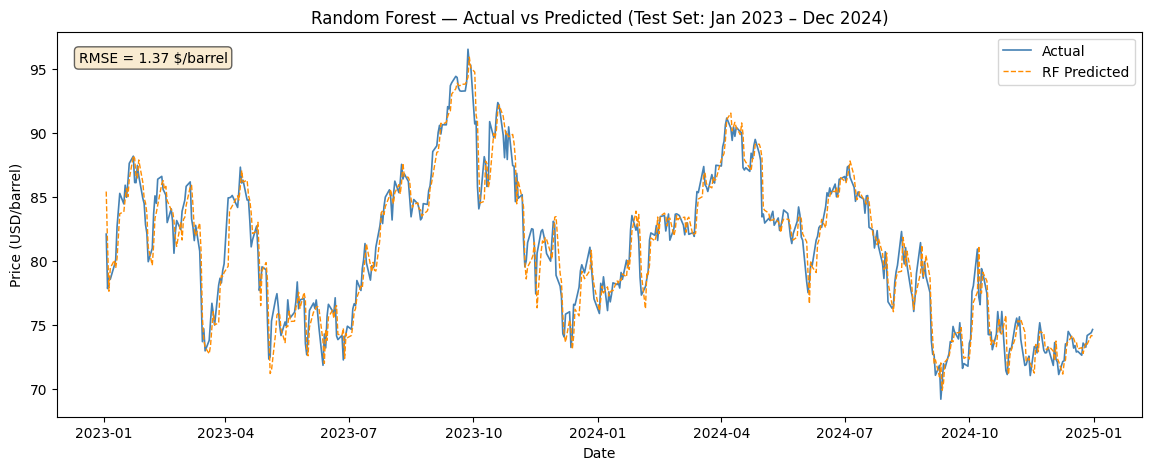

Plot saved.


In [5]:
# Random Forest — Actual vs Predicted plot
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(test_f.index, y_test,    label="Actual",
        color="steelblue", lw=1.2)
ax.plot(test_f.index, y_pred_rf, label="RF Predicted",
        color="darkorange", lw=1.0, linestyle="--")
ax.text(0.02, 0.95,
        f"RMSE = {metrics_rf['RMSE']:.2f} $/barrel",
        transform=ax.transAxes, fontsize=10,
        verticalalignment="top",
        bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.6))
ax.set_title("Random Forest — Actual vs Predicted "
             "(Test Set: Jan 2023 – Dec 2024)")
ax.set_ylabel("Price (USD/barrel)")
ax.set_xlabel("Date")
ax.legend()
plt.savefig("artifacts/plots/rf_actual_vs_predicted.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Plot saved.")

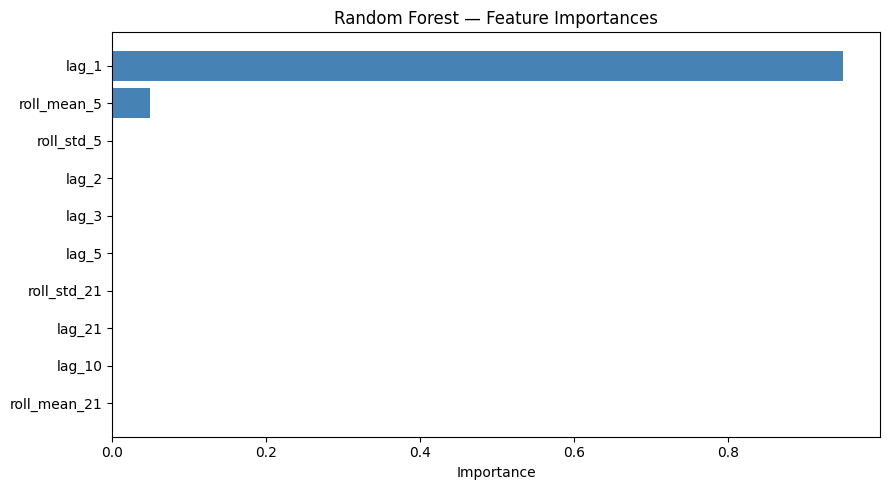

Plot saved.


In [6]:
# Random Forest feature importances
importances = best_rf.feature_importances_
top_idx = np.argsort(importances)[::-1]

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh([feat_names[i] for i in top_idx[::-1]],
        [importances[i] for i in top_idx[::-1]],
        color="steelblue")
ax.set_title("Random Forest — Feature Importances")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.savefig("artifacts/plots/rf_feature_importances.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Plot saved.")

In [7]:
# Save Random Forest results
os.makedirs("results/random_forest", exist_ok=True)

save_predictions(test_f.index, y_test, y_pred_rf,
                 "results/random_forest/rf_test_predictions.csv")
save_metrics(metrics_rf,
             "results/random_forest/rf_metrics.json")

Predictions saved to results/random_forest/rf_test_predictions.csv
Metrics saved to results/random_forest/rf_metrics.json


In [8]:
## XGBoost — RandomizedSearchCV with TimeSeriesSplit
xgb_param_grid = {
    "n_estimators":     cfg["models"]["xgboost"]["n_estimators"],
    "max_depth":        cfg["models"]["xgboost"]["max_depth"],
    "learning_rate":    cfg["models"]["xgboost"]["learning_rate"],
    "subsample":        cfg["models"]["xgboost"]["subsample"],
    "colsample_bytree": cfg["models"]["xgboost"]["colsample_bytree"],
}

xgb_search = RandomizedSearchCV(
    XGBRegressor(random_state=42, objective="reg:squarederror",
                 verbosity=0, n_jobs=-1),
    xgb_param_grid,
    n_iter=cfg["models"]["xgboost"]["cv_n_iter"],
    cv=tscv,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
    random_state=42,
    verbose=1
)

print("Running XGBoost hyperparameter search...")
print("This may take 5-10 minutes...")
xgb_search.fit(X_train, y_train)

print(f"\nBest XGB params: {xgb_search.best_params_}")
print(f"Best CV RMSE:    {-xgb_search.best_score_:.4f} $/barrel")

Running XGBoost hyperparameter search...
This may take 5-10 minutes...
Fitting 5 folds for each of 50 candidates, totalling 250 fits

Best XGB params: {'subsample': 0.8, 'n_estimators': 500, 'max_depth': 3, 'learning_rate': 0.01, 'colsample_bytree': 0.6}
Best CV RMSE:    9.4114 $/barrel


In [9]:
# Refit best XGBoost on train+val combined, predict on test
best_xgb = xgb_search.best_estimator_
best_xgb.fit(X_tv, y_tv)

y_pred_xgb  = best_xgb.predict(X_test)
metrics_xgb = calculate_metrics(y_test, y_pred_xgb)

print("\n─── XGBoost Test Set Metrics ─────────────────────────")
print(f"  RMSE : {metrics_xgb['RMSE']:.4f} $/barrel")
print(f"  MAE  : {metrics_xgb['MAE']:.4f} $/barrel")
print(f"  MAPE : {metrics_xgb['MAPE']:.4f} %")
print(f"\nARIMA baseline RMSE: 1.4584 $/barrel")
print(f"RF RMSE:             1.3744 $/barrel")
print(f"XGB vs ARIMA: {'BETTER' if metrics_xgb['RMSE'] < 1.4584 else 'WORSE'}")
print(f"XGB vs RF:    {'BETTER' if metrics_xgb['RMSE'] < 1.3744 else 'WORSE'}")

─── Metrics ──────────────────────
  RMSE : 1.4477 $/barrel
  MAE  : 1.1303 $/barrel
  MAPE : 1.4038 %

─── XGBoost Test Set Metrics ─────────────────────────
  RMSE : 1.4477 $/barrel
  MAE  : 1.1303 $/barrel
  MAPE : 1.4038 %

ARIMA baseline RMSE: 1.4584 $/barrel
RF RMSE:             1.3744 $/barrel
XGB vs ARIMA: BETTER
XGB vs RF:    WORSE


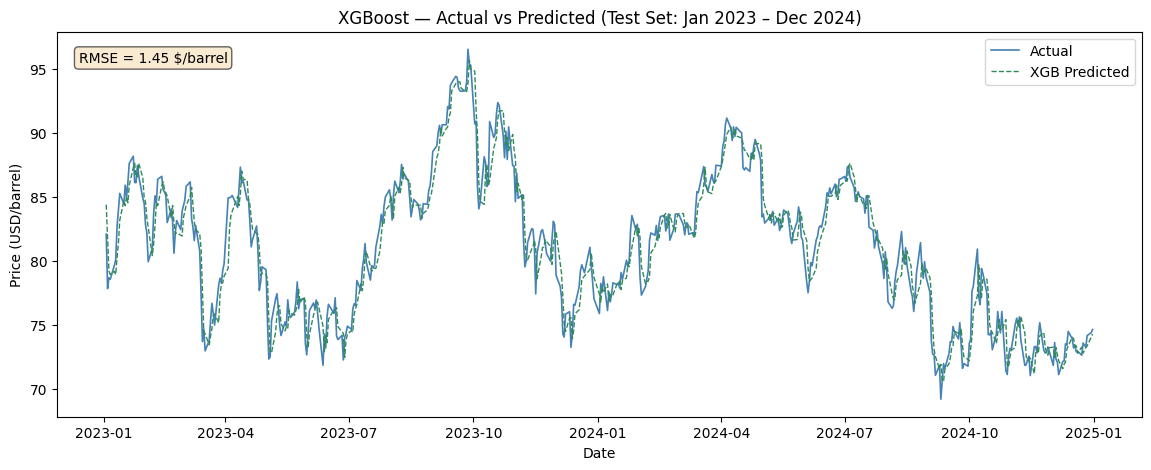

Plot saved.


In [10]:
# XGBoost — Actual vs Predicted plot
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(test_f.index, y_test,     label="Actual",
        color="steelblue", lw=1.2)
ax.plot(test_f.index, y_pred_xgb, label="XGB Predicted",
        color="seagreen", lw=1.0, linestyle="--")
ax.text(0.02, 0.95,
        f"RMSE = {metrics_xgb['RMSE']:.2f} $/barrel",
        transform=ax.transAxes, fontsize=10,
        verticalalignment="top",
        bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.6))
ax.set_title("XGBoost — Actual vs Predicted "
             "(Test Set: Jan 2023 – Dec 2024)")
ax.set_ylabel("Price (USD/barrel)")
ax.set_xlabel("Date")
ax.legend()
plt.savefig("artifacts/plots/xgb_actual_vs_predicted.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Plot saved.")

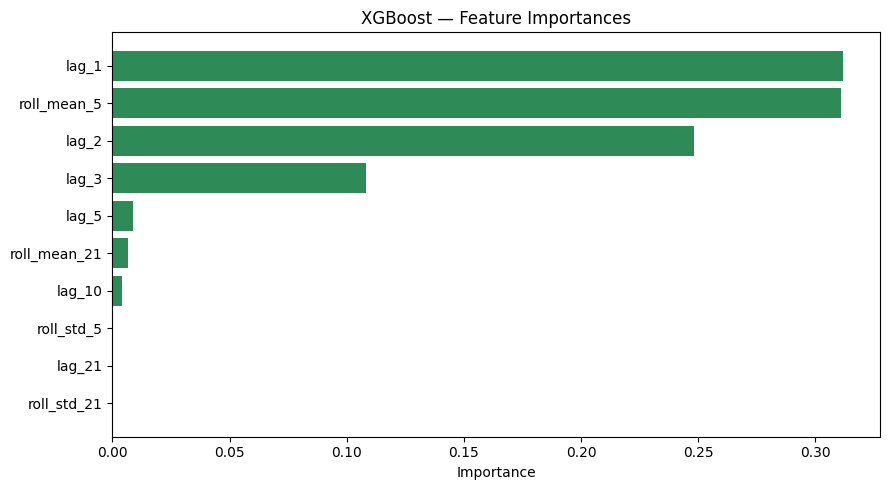

Plot saved.


In [11]:
# XGBoost feature importances
xgb_imp = best_xgb.feature_importances_
top_idx2 = np.argsort(xgb_imp)[::-1]

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh([feat_names[i] for i in top_idx2[::-1]],
        [xgb_imp[i] for i in top_idx2[::-1]],
        color="seagreen")
ax.set_title("XGBoost — Feature Importances")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.savefig("artifacts/plots/xgb_feature_importances.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Plot saved.")

In [12]:
# Save XGBoost results
os.makedirs("results/xgboost", exist_ok=True)

save_predictions(test_f.index, y_test, y_pred_xgb,
                 "results/xgboost/xgb_test_predictions.csv")
save_metrics(metrics_xgb,
             "results/xgboost/xgb_metrics.json")

Predictions saved to results/xgboost/xgb_test_predictions.csv
Metrics saved to results/xgboost/xgb_metrics.json


In [13]:
# ML models comparison table
with open("results/arima/arima_metrics.json") as f:
    m_arima = json.load(f)

rows = [
    ("ARIMA",         m_arima),
    ("Random Forest", metrics_rf),
    ("XGBoost",       metrics_xgb),
]

comp = pd.DataFrame(
    [(r[0], r[1]["RMSE"], r[1]["MAE"], r[1]["MAPE"]) for r in rows],
    columns=["Model", "RMSE ($/barrel)", "MAE ($/barrel)", "MAPE (%)"]
).sort_values("RMSE ($/barrel)").reset_index(drop=True)
comp.index += 1
comp["Rank"] = comp.index

print("─── ML Models Comparison (sorted by RMSE) ───────────")
print(comp.round(4).to_string())

─── ML Models Comparison (sorted by RMSE) ───────────
           Model  RMSE ($/barrel)  MAE ($/barrel)  MAPE (%)  Rank
1  Random Forest           1.3744          1.0458    1.3004     1
2        XGBoost           1.4477          1.1303    1.4038     2
3          ARIMA           1.4584          1.1167    1.3917     3


### ML Models Results

### Performance summary
| Model | RMSE ($/barrel) | MAE ($/barrel) | MAPE (%) | Rank |
|-------|----------------|----------------|----------|------|
| Random Forest | 1.3744 | 1.0458 | 1.30% | 1 |
| XGBoost | 1.4477 | 1.1303 | 1.40% | 2 |
| ARIMA baseline | 1.4584 | 1.1167 | 1.39% | 3 |

### Key findings
- Both ML models outperform the ARIMA baseline on all metrics
- Random Forest outperforms XGBoost despite XGBoost's greater 
  complexity
- Random Forest feature importance shows lag_1 dominates (93%) — 
  suggesting a near-persistence forecast
- XGBoost distributes importance more evenly across lag_1, 
  roll_mean_5, and lag_2 — indicating broader temporal pattern use
- The benchmark for deep learning models is now Random Forest 
  RMSE = 1.3744 $/barrel